In [201]:
%pwd

'/home/ahmed/CV_ADD_PROJECT/MachineLearning/Shipment-Price-Prediction-System-ML-AWS-'

In [202]:
# import os
# os.chdir('../')

In [203]:
%pwd

'/home/ahmed/CV_ADD_PROJECT/MachineLearning/Shipment-Price-Prediction-System-ML-AWS-'

In [204]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [205]:
df = pd.read_csv('Data/Shipment-data.csv')
df.shape

(6500, 20)

In [206]:
df.head()

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,06/07/15,06/03/15,"New Michelle, OH 50777",-283.29
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,03/06/17,03/05/17,"New Michaelport, WY 12072",-159.96
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,No,No,Roadways,Yes,Working Class,Yes,03/09/15,03/08/15,"Bowmanshire, WA 19241",-154.29
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,No,No,NaN,No,Wealthy,Yes,05/24/15,05/20/15,"East Robyn, KY 86375",-161.16
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,12/18/16,12/14/16,"Aprilside, PA 52793",-159.23


In [207]:
df.columns

Index(['Customer Id', 'Artist Name', 'Artist Reputation', 'Height', 'Width',
       'Weight', 'Material', 'Price Of Sculpture', 'Base Shipping Price',
       'International', 'Express Shipment', 'Installation Included',
       'Transport', 'Fragile', 'Customer Information', 'Remote Location',
       'Scheduled Date', 'Delivery Date', 'Customer Location', 'Cost'],
      dtype='object')

### Null value Check

In [208]:
df.isnull().mean()

Customer Id              0.000000
Artist Name              0.000000
Artist Reputation        0.115385
Height                   0.057692
Width                    0.089846
Weight                   0.090308
Material                 0.117538
Price Of Sculpture       0.000000
Base Shipping Price      0.000000
International            0.000000
Express Shipment         0.000000
Installation Included    0.000000
Transport                0.214154
Fragile                  0.000000
Customer Information     0.000000
Remote Location          0.118615
Scheduled Date           0.000000
Delivery Date            0.000000
Customer Location        0.000000
Cost                     0.000000
dtype: float64

In [209]:
feature_with_na = [feature for feature in df.columns if df[feature].isnull().sum() > 1]

for feature in feature_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,3), '% missing values')

Artist Reputation 11.538 % missing values
Height 5.769 % missing values
Width 8.985 % missing values
Weight 9.031 % missing values
Material 11.754 % missing values
Transport 21.415 % missing values
Remote Location 11.862 % missing values


# Missing Value Handling Strategy

## Overview

Missing values are one of the most common problems in real-world datasets. Improper handling can lead to biased models, reduced prediction accuracy, and unreliable business decisions.

Before model training, every missing value should be analyzed and treated using an appropriate strategy based on:

* Missing percentage
* Feature type
* Business meaning
* Model requirements

---

# Types of Missing Data

## 1. MCAR (Missing Completely At Random)

Missing values occur randomly.

Example:

```text
Weight value missing due to system failure.
```

No relationship exists between the missing value and other variables.

### Recommended Treatment

* Mean Imputation
* Median Imputation
* KNN Imputation

---

## 2. MAR (Missing At Random)

Missing values depend on another feature.

Example:

```text
Remote Location is missing mostly for domestic shipments.
```

### Recommended Treatment

* Group-Based Imputation
* KNN Imputation
* Iterative Imputation

---

## 3. MNAR (Missing Not At Random)

Missing values themselves contain information.

Example:

```text
High-value artwork prices intentionally hidden.
```

### Recommended Treatment

* Create Missing Indicator Feature
* Business Investigation
* Domain-Specific Handling

---

# Missing Value Handling Techniques

## Method 1: Drop Rows

### Description

Remove records containing missing values.

```python
df.dropna()
```

### Advantages

* Simple
* Fast

### Disadvantages

* Data loss
* Risk of losing important patterns

### Use When

```text
Missing < 5%
Dataset is very large
```

---

## Method 2: Mean Imputation

### Description

Replace missing values with average value.

```python
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
```

### Advantages

* Easy implementation

### Disadvantages

* Sensitive to outliers

### Suitable For

```text
Normally distributed features
```

---

## Method 3: Median Imputation

### Description

Replace missing values with median.

```python
imputer = SimpleImputer(strategy="median")
```

### Advantages

* Robust against outliers
* Works well on skewed data

### Suitable For

```text
Weight
Price Of Sculpture
Height
Width
Artist Reputation
```

### Industry Recommendation

Preferred for this project.

---

## Method 4: Mode Imputation

### Description

Replace missing categorical values with most frequent category.

```python
imputer = SimpleImputer(strategy="most_frequent")
```

### Suitable For

```text
Transport
Material
Remote Location
```

---

## Method 5: Constant Value Imputation

### Description

Replace missing values with a fixed value.

Example:

```python
df["Transport"] = df["Transport"].fillna("Unknown")
```

### Advantages

* Preserves missing information
* Business-friendly

### Industry Recommendation

Highly recommended for categorical features.

---

## Method 6: KNN Imputation

### Description

Uses neighboring observations to estimate missing values.

```python
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
```

### Advantages

* More accurate

### Disadvantages

* Computationally expensive

### Use When

```text
Small or medium-sized datasets
```

---

## Method 7: Iterative Imputation (MICE)

### Description

Predicts missing values using other features.

```python
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
```

### Advantages

* Advanced method
* Often highly accurate

### Disadvantages

* Slow training

### Industry Usage

Common in healthcare and finance datasets.

---

## Method 8: Missing Indicator

### Description

Create a new feature indicating whether a value was missing.

```python
df["Weight_Missing"] = df["Weight"].isnull().astype(int)
```

### Advantages

* Preserves hidden information

### Example

```text
Missing weight may itself affect shipment pricing.
```

---

# Missing Value Analysis for Shipment Price Prediction

## Numerical Features

| Feature           | Missing Count | Strategy |
| ----------------- | ------------- | -------- |
| Artist Reputation | 750           | Median   |
| Height            | 375           | Median   |
| Width             | 584           | Median   |
| Weight            | 587           | Median   |

### Reason

These features are highly skewed and contain outliers.

Median imputation is more robust than mean imputation.

---

## Categorical Features

| Feature         | Missing Count | Strategy |
| --------------- | ------------- | -------- |
| Material        | 764           | Unknown  |
| Transport       | 1392          | Unknown  |
| Remote Location | 771           | Unknown  |

### Reason

Missing category itself may contain useful business information.

---

# Recommended Production Pipeline

## Numerical Pipeline

```python
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
```

---

## Categorical Pipeline

```python
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(
    strategy="constant",
    fill_value="Unknown"
)
```

### correlation check

In [210]:
# Correlation with target
df.corr(
    numeric_only=True
)['Cost'].sort_values(
    ascending=False
)

Cost                   1.000000
Price Of Sculpture     0.476231
Weight                 0.417263
Width                  0.158159
Height                 0.106047
Artist Reputation      0.067368
Base Shipping Price    0.053068
Name: Cost, dtype: float64

### Duplicated Check

In [211]:
df.duplicated().sum()

np.int64(0)

In [212]:
df.duplicated().T.sum()

np.int64(0)

### # Skewness Check

In [213]:
df.select_dtypes(
    include=np.number
).skew()

Artist Reputation       0.141363
Height                  0.594041
Width                   1.546702
Weight                 21.556174
Price Of Sculpture     22.206823
Base Shipping Price     0.918102
Cost                   29.817459
dtype: float64

### Seperate Feature

In [214]:
# Numerical Columns
TARGET_COLUMN = 'Cost'

numerical_cols = [
    col for col in df.select_dtypes(
        include=['int64', 'float64']
    ).columns
    if col != TARGET_COLUMN
]

# Categorical Columns
categorical_cols = [
    col for col in df.select_dtypes(
        include=['object']
    ).columns
]

# Print Results
print("Numerical Columns:\n")
print(numerical_cols)

print("\nCategorical Columns:\n")
print(categorical_cols)

Numerical Columns:

['Artist Reputation', 'Height', 'Width', 'Weight', 'Price Of Sculpture', 'Base Shipping Price']

Categorical Columns:

['Customer Id', 'Artist Name', 'Material', 'International', 'Express Shipment', 'Installation Included', 'Transport', 'Fragile', 'Customer Information', 'Remote Location', 'Scheduled Date', 'Delivery Date', 'Customer Location']


### Multicollinearity Check
`Multicollinearity happens when two or more input features are highly correlated with each other.`
- It mainly affects Linear Models (like Linear Regression).

In [215]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df1 = df.copy()
X = df1[numerical_cols].copy()
X = X.fillna(X.median())
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data.sort_values(by="VIF", ascending=False))

               Feature       VIF
0                const  9.274076
4               Weight  4.284500
5   Price Of Sculpture  4.234846
3                Width  2.132813
2               Height  2.066713
6  Base Shipping Price  1.150158
1    Artist Reputation  1.005484


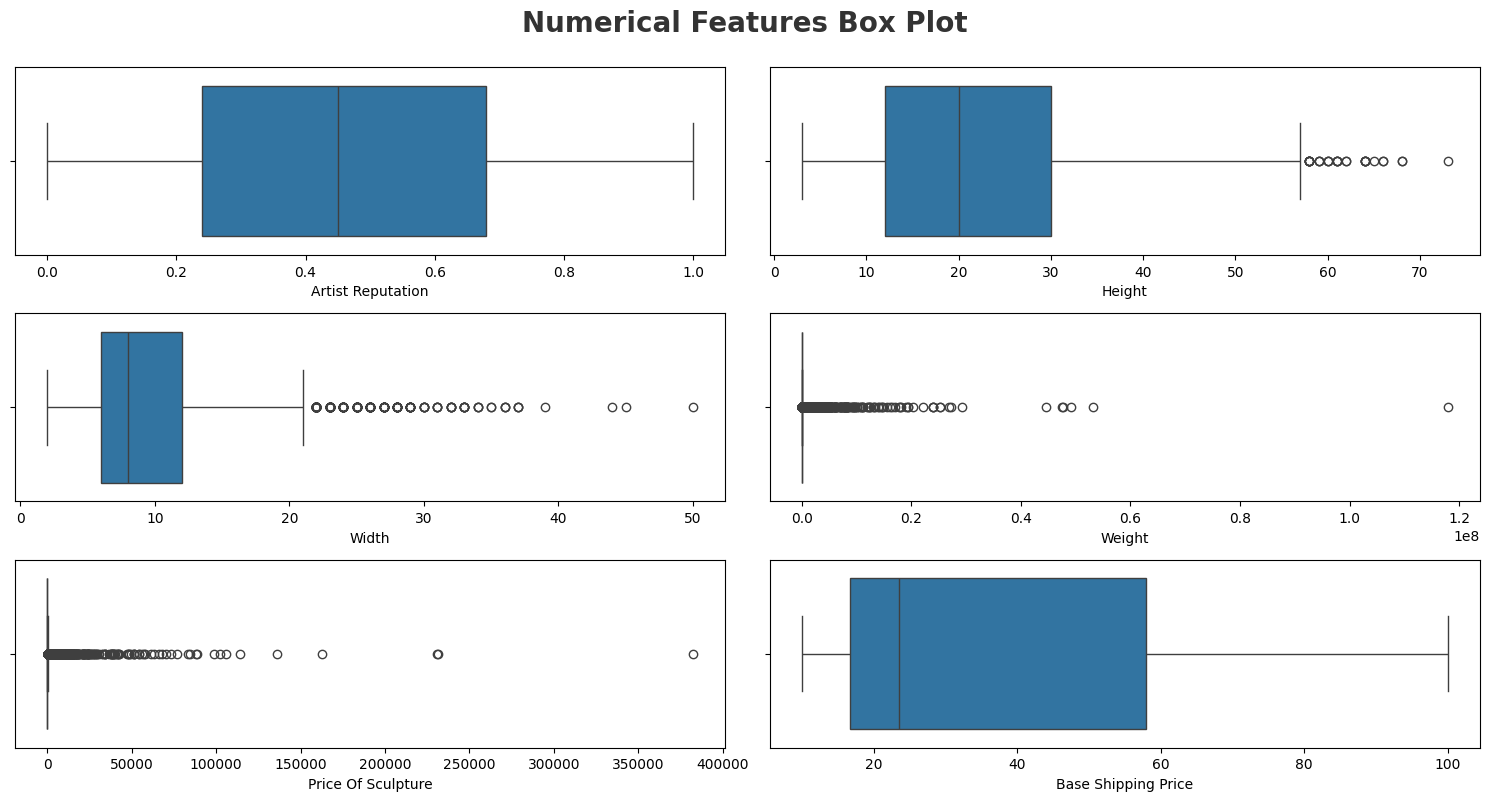

In [216]:
plt.figure(figsize=(15, 10))
plt.suptitle('Numerical Features Box Plot',
             fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(len(numerical_cols)):
    plt.subplot(4, 2, i+1)
    sns.boxplot(x=df[numerical_cols[i]])
    plt.xlabel(numerical_cols[i])

plt.tight_layout()
plt.show()

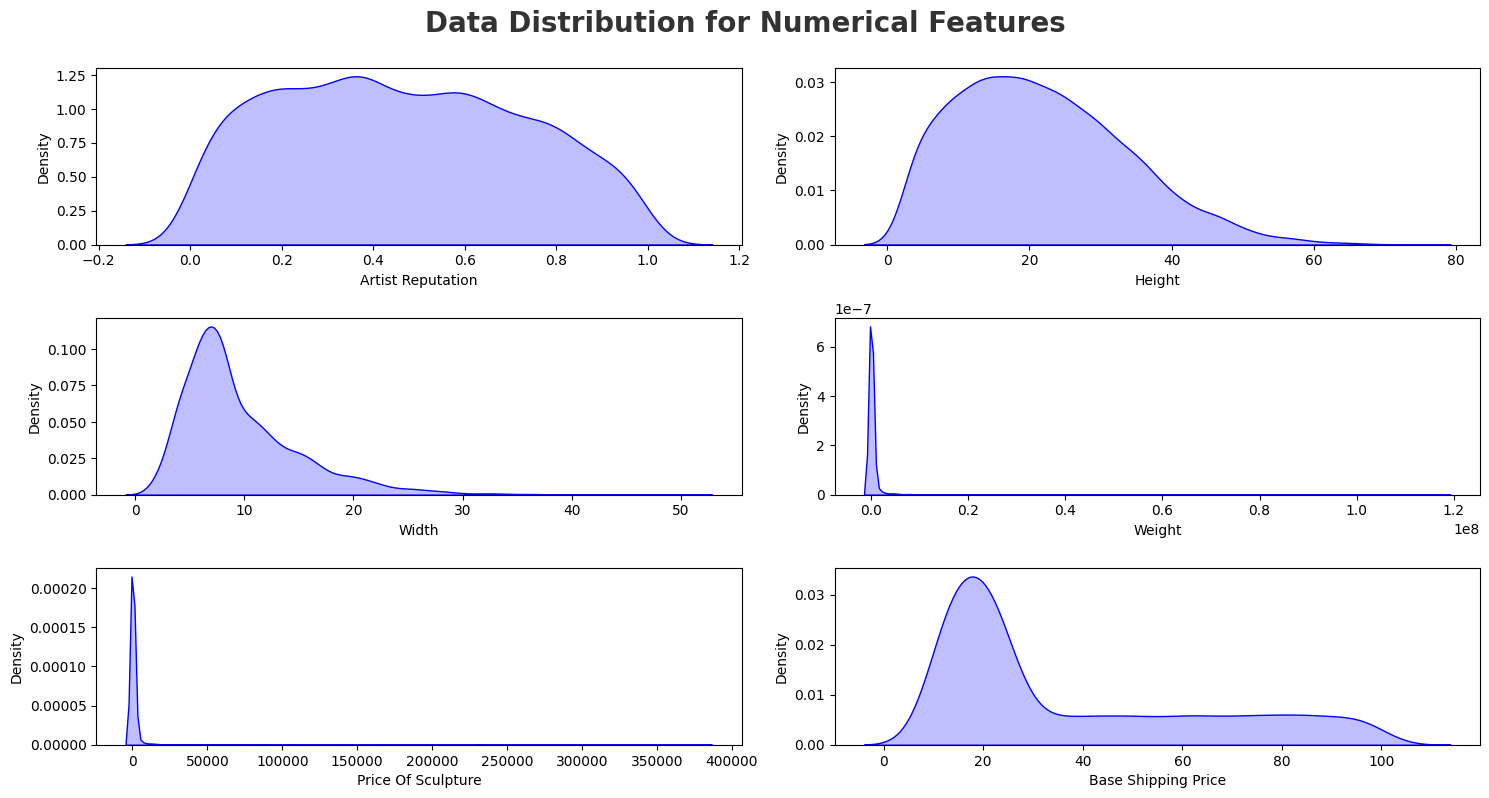

In [217]:
plt.figure(figsize=(15, 10))
plt.suptitle('Data Distribution for Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numerical_cols)):
    plt.subplot(4, 2, i+1)
    sns.kdeplot(x=df[numerical_cols[i]],fill=True, color='blue')
    plt.xlabel(numerical_cols[i])
plt.tight_layout()

In [218]:
df

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,06/07/15,06/03/15,"New Michelle, OH 50777",-283.29
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,03/06/17,03/05/17,"New Michaelport, WY 12072",-159.96
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,No,No,Roadways,Yes,Working Class,Yes,03/09/15,03/08/15,"Bowmanshire, WA 19241",-154.29
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,No,No,NaN,No,Wealthy,Yes,05/24/15,05/20/15,"East Robyn, KY 86375",-161.16
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,12/18/16,12/14/16,"Aprilside, PA 52793",-159.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6495,fffe3800370037003300,Jeffrey Freudenthal,0.37,37.0,10.0,16551.0,Brass,28.28,38.46,Yes,Yes,No,Airways,No,Wealthy,Yes,03/28/18,03/25/18,"New Robert, VT 85335",872.43
6496,fffe310036003400,Larry Edwards,0.67,15.0,NaN,18981.0,NaN,67.18,27.72,No,No,No,Roadways,No,Working Class,No,08/29/15,08/27/15,"New Joshua, VA 35766",1347.02
6497,fffe3600300031003300,Denise Worth,0.68,19.0,8.0,587.0,Clay,6.92,10.38,Yes,No,No,NaN,Yes,Wealthy,No,04/10/19,04/09/19,"Lake Kelly, MA 80823",354.55
6498,fffe3600350035003900,Daniel Drew,0.02,33.0,9.0,1269377.0,Stone,2929.13,69.76,No,Yes,No,Roadways,No,Working Class,Yes,03/10/19,03/12/19,"Hintonberg, UT 35006",5037.50


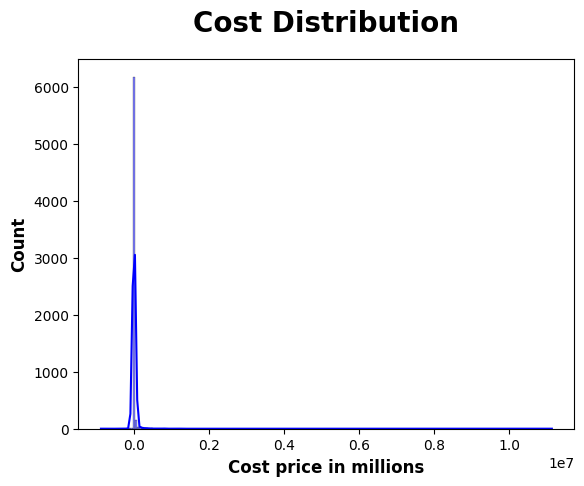

In [219]:
sns.histplot(df['Cost'], bins=200, kde=True, color = 'b')
plt.title("Cost Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Cost price in millions", weight="bold", fontsize=12)
plt.show()

In [220]:
# df['Cost'] = np.log1p(df['Cost'])
(df['Cost'] < 0).sum()

np.int64(659)

In [221]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer, LabelEncoder, OrdinalEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

### power transformer

In [222]:
power_features_outlier = [
    'Weight',
    'Price Of Sculpture'
]

pt = PowerTransformer(method='yeo-johnson')

df[power_features_outlier] = pt.fit_transform(df[power_features_outlier])

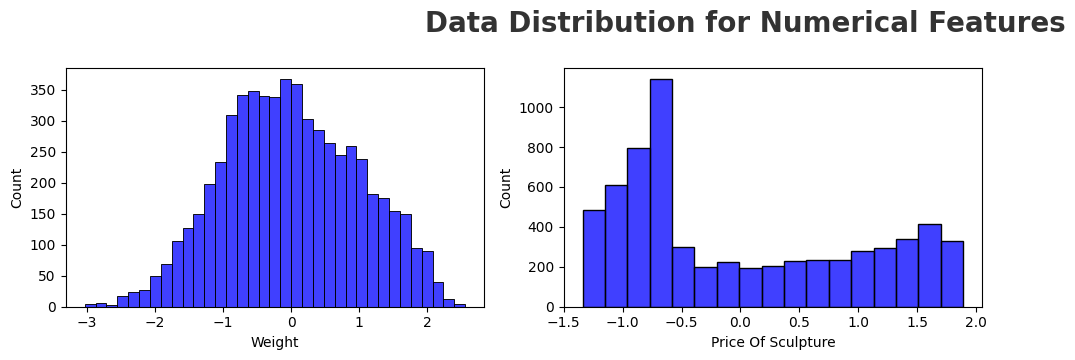

In [223]:
plt.figure(figsize=(15, 15))
plt.suptitle('Data Distribution for Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(power_features_outlier)):
    plt.subplot(5, 3, i+1)
    sns.histplot(x=df[power_features_outlier[i]], color='b')
    plt.xlabel(power_features_outlier[i])
    plt.tight_layout()

In [224]:
df[power_features_outlier].skew()


Weight                0.043289
Price Of Sculpture    0.478648
dtype: float64

**Insights**
 - Power transformer does a better job at overcoming skewness and handling outliers
 
**Why outliers?**
* Data Entry error : Human error. 
* Measurement error: Instrument error. 
* Natural error: it will be Real life data.
* Intentional error: People give wrong inputs

**Impact of Outliers ?**
* Ouliers can very high impact on few Machine learning models.
* Can Cause bias in the output.

### Feature Transform&Enginnering

#### Date-Time Convert

In [225]:
# Convert
df['Scheduled Date'] = pd.to_datetime(df['Scheduled Date'])
df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])

df['Scheduled_Month'] = df['Scheduled Date'].dt.month
# df['Scheduled_Year'] = df['Scheduled Date'].dt.year

# df["Delivery_Days"] = (
#     df["Delivery Date"] -
#     df["Scheduled Date"]
# ).dt.days

df["Delivery_Days"] = (
    df["Scheduled Date"] -
    df["Delivery Date"]
).dt.days

/tmp/ipykernel_9099/847720007.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Scheduled Date'] = pd.to_datetime(df['Scheduled Date'])
/tmp/ipykernel_9099/847720007.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])


In [226]:
df

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,...,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost,Scheduled_Month,Delivery_Days
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,0.049990,Brass,-0.022812,16.27,Yes,...,Airways,No,Working Class,No,2015-06-07,2015-06-03,"New Michelle, OH 50777",-283.29,6,4
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,-1.630574,Brass,-0.583447,15.00,No,...,Roadways,No,Working Class,No,2017-03-06,2017-03-05,"New Michaelport, WY 12072",-159.96,3,1
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,-1.036710,Clay,-0.867195,21.18,No,...,Roadways,Yes,Working Class,Yes,2015-03-09,2015-03-08,"Bowmanshire, WA 19241",-154.29,3,1
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,-0.724773,16.31,No,...,NaN,No,Wealthy,Yes,2015-05-24,2015-05-20,"East Robyn, KY 86375",-161.16,5,4
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,-0.907069,Aluminium,-1.284551,11.94,Yes,...,Airways,No,Working Class,No,2016-12-18,2016-12-14,"Aprilside, PA 52793",-159.23,12,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6495,fffe3800370037003300,Jeffrey Freudenthal,0.37,37.0,10.0,0.504203,Brass,0.430801,38.46,Yes,...,Airways,No,Wealthy,Yes,2018-03-28,2018-03-25,"New Robert, VT 85335",872.43,3,3
6496,fffe310036003400,Larry Edwards,0.67,15.0,NaN,0.546635,NaN,0.853104,27.72,No,...,Roadways,No,Working Class,No,2015-08-29,2015-08-27,"New Joshua, VA 35766",1347.02,8,2
6497,fffe3600300031003300,Denise Worth,0.68,19.0,8.0,-0.668145,Clay,-0.572214,10.38,Yes,...,NaN,Yes,Wealthy,No,2019-04-10,2019-04-09,"Lake Kelly, MA 80823",354.55,4,1
6498,fffe3600350035003900,Daniel Drew,0.02,33.0,9.0,1.666634,Stone,1.681296,69.76,No,...,Roadways,No,Working Class,Yes,2019-03-10,2019-03-12,"Hintonberg, UT 35006",5037.50,3,-2


<Axes: xlabel='Scheduled_Month', ylabel='Cost'>

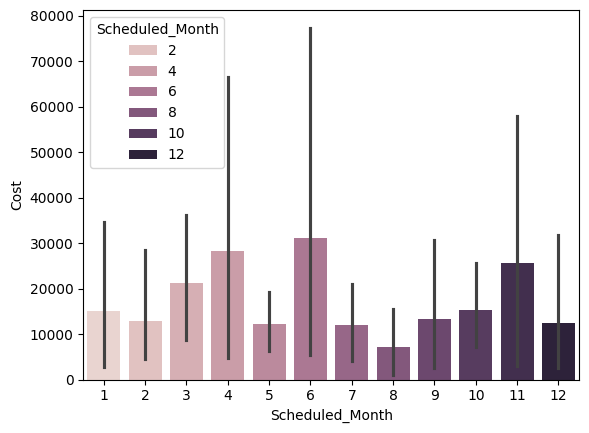

In [227]:
sns.barplot(data=df,x=df['Scheduled_Month'],y = df['Cost'],hue=df['Scheduled_Month'])

In [228]:
df1['Customer Location'].str.split(',').str[1].str.strip().str.split(' ').str[0]

0       OH
1       WY
2       WA
3       KY
4       PA
        ..
6495    VT
6496    VA
6497    MA
6498    UT
6499    AK
Name: Customer Location, Length: 6500, dtype: object

In [229]:
df1['Customer Location'].str.split(',').str[0]

0          New Michelle
1       New Michaelport
2           Bowmanshire
3            East Robyn
4             Aprilside
             ...       
6495         New Robert
6496         New Joshua
6497         Lake Kelly
6498         Hintonberg
6499    New Christopher
Name: Customer Location, Length: 6500, dtype: object

In [230]:
# df['Price_per_Weight'] = df['Price Of Sculpture'] / (df['Weight'] + 1)
# df['Size'] = df['Height'] * df['Width']
# df['Price_per_Size'] = df['Price Of Sculpture'] / (df['Size'] + 1)

In [231]:
# df[['Weight','Height','Width','Size', 'Cost']].corr()['Cost']

### Drop Columns

In [232]:
drop_cols = [
    'Customer Id',
    'Artist Name',
    'Customer Location',
    'Scheduled Date',
    'Delivery Date'
]

df.drop(columns=drop_cols, inplace=True)

In [233]:
# Numerical Columns
TARGET_COLUMN = 'Cost'

numerical_cols = [
    col for col in df.select_dtypes(
        include=['int64', 'float64']
    ).columns
    if col != TARGET_COLUMN
]

# Categorical Columns
categorical_cols = [
    col for col in df.select_dtypes(
        include=['object']
    ).columns
]

# Print Results
print("Numerical Columns:\n")
print(numerical_cols)

print("\nCategorical Columns:\n")
print(categorical_cols)

Numerical Columns:

['Artist Reputation', 'Height', 'Width', 'Weight', 'Price Of Sculpture', 'Base Shipping Price', 'Delivery_Days']

Categorical Columns:

['Material', 'International', 'Express Shipment', 'Installation Included', 'Transport', 'Fragile', 'Customer Information', 'Remote Location']


In [234]:
df.head()

,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Cost,Scheduled_Month,Delivery_Days
0,0.26,17.0,6.0,0.049990,Brass,-0.022812,16.27,Yes,Yes,No,Airways,No,Working Class,No,-283.29,6,4
1,0.28,3.0,3.0,-1.630574,Brass,-0.583447,15.00,No,No,No,Roadways,No,Working Class,No,-159.96,3,1
2,0.07,8.0,5.0,-1.036710,Clay,-0.867195,21.18,No,No,No,Roadways,Yes,Working Class,Yes,-154.29,3,1
3,0.12,9.0,NaN,NaN,Aluminium,-0.724773,16.31,No,No,No,NaN,No,Wealthy,Yes,-161.16,5,4
4,0.15,17.0,6.0,-0.907069,Aluminium,-1.284551,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,-159.23,12,4


In [235]:
x = df.drop(columns = ['Cost'], axis=1)
y = np.abs(df['Cost'])

y = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

### Train-Test Distribution Analysis

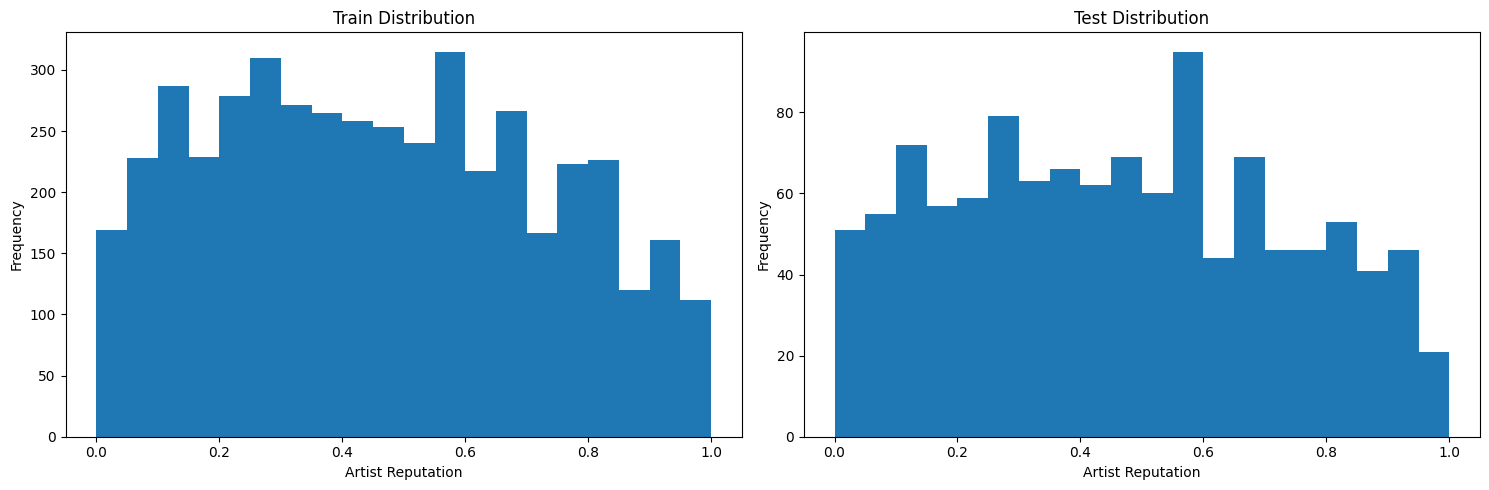

In [236]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(X_train["Artist Reputation"], bins=20)
axes[0].set_title("Train Distribution")
axes[0].set_xlabel("Artist Reputation")
axes[0].set_ylabel("Frequency")

axes[1].hist(X_test["Artist Reputation"], bins=20)
axes[1].set_title("Test Distribution")
axes[1].set_xlabel("Artist Reputation")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

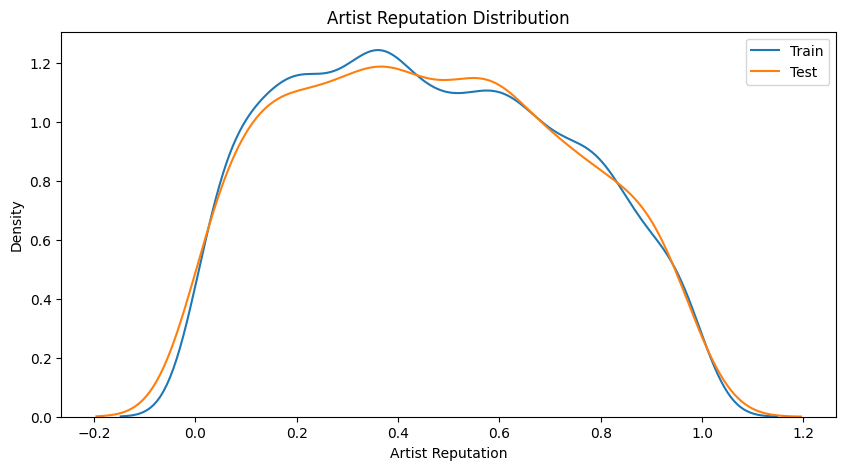

In [237]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    X_train["Artist Reputation"],
    label="Train"
)

sns.kdeplot(
    X_test["Artist Reputation"],
    label="Test"
)

plt.title("Artist Reputation Distribution")
plt.xlabel("Artist Reputation")
plt.legend()

plt.show()

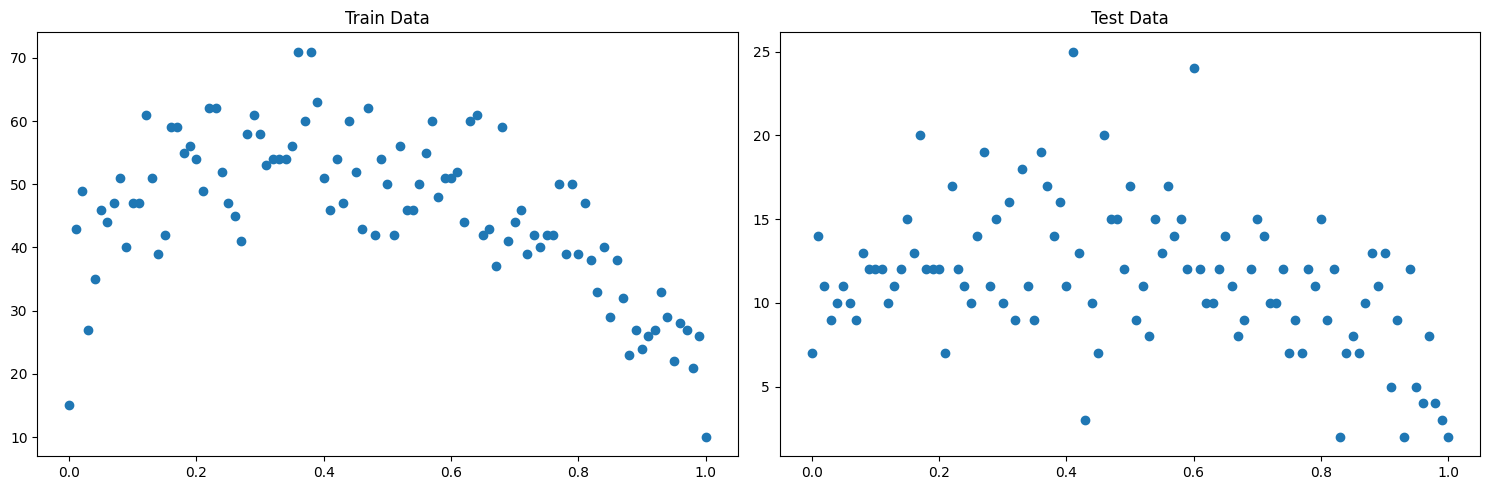

In [238]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

train_counts = X_train["Artist Reputation"].value_counts()
test_counts = X_test["Artist Reputation"].value_counts()

axes[0].scatter(
    train_counts.index,
    train_counts.values
)
axes[0].set_title("Train Data")

axes[1].scatter(
    test_counts.index,
    test_counts.values
)
axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

In [239]:
# numerical_cols
categorical_cols

['Material',
 'International',
 'Express Shipment',
 'Installation Included',
 'Transport',
 'Fragile',
 'Customer Information',
 'Remote Location']

In [240]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])



preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)

In [241]:
X_train_array = preprocessor.fit_transform(X_train)
X_test_array = preprocessor.transform(X_test)

## Model Selection 

In [242]:
# functions which takes true and predicted values to calculate metrics
def evaluate_reg(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [243]:
def evaluate_models(X_train, X_test, y_train, y_test, models):

    reports = []

    for model_name, model in models.items():

        try:

            # Train
            model.fit(X_train, y_train)

            # Prediction
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            # Metrics
            train_mae, train_rmse, train_r2 = evaluate_reg(
                y_train,
                y_train_pred
            )

            test_mae, test_rmse, test_r2 = evaluate_reg(
                y_test,
                y_test_pred
            )

            reports.append({
                "Model": model_name,
                "Train_R2": round(train_r2, 4),
                "Test_R2": round(test_r2, 4),
                "Train_RMSE": round(train_rmse, 4),
                "Test_RMSE": round(test_rmse, 4),
                "Train_MAE": round(train_mae, 4),
                "Test_MAE": round(test_mae, 4)
            })

            print(f"\n{'='*50}")
            print(f"Model : {model_name}")
            print(f"{'='*50}")

            print("Train Metrics")
            print(f"R2   : {train_r2:.4f}")
            print(f"RMSE : {train_rmse:.4f}")
            print(f"MAE  : {train_mae:.4f}")

            print("\nTest Metrics")
            print(f"R2   : {test_r2:.4f}")
            print(f"RMSE : {test_rmse:.4f}")
            print(f"MAE  : {test_mae:.4f}")

        except Exception as e:

            print(f"Error in {model_name}: {e}")

    report_df = pd.DataFrame(reports)

    report_df = report_df.sort_values(
        by="Test_R2",
        ascending=False
    )

    return report_df

In [244]:
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),
}

In [245]:
report = evaluate_models(
    X_train_array,
    X_test_array,
    y_train,
    y_test,
    models
)

report


Model : Decision Tree
Train Metrics
R2   : 1.0000
RMSE : 0.0000
MAE  : 0.0000

Test Metrics
R2   : 0.9009
RMSE : 0.5194
MAE  : 0.3098

Model : Random Forest
Train Metrics
R2   : 0.9945
RMSE : 0.1220
MAE  : 0.0769

Test Metrics
R2   : 0.9558
RMSE : 0.3468
MAE  : 0.2005

Model : XGBoost
Train Metrics
R2   : 0.9968
RMSE : 0.0936
MAE  : 0.0595

Test Metrics
R2   : 0.9612
RMSE : 0.3251
MAE  : 0.1771

Model : CatBoost
Train Metrics
R2   : 0.9916
RMSE : 0.1515
MAE  : 0.0911

Test Metrics
R2   : 0.9733
RMSE : 0.2698
MAE  : 0.1463


,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE
3,CatBoost,0.9916,0.9733,0.1515,0.2698,0.0911,0.1463
2,XGBoost,0.9968,0.9612,0.0936,0.3251,0.0595,0.1771
1,Random Forest,0.9945,0.9558,0.1220,0.3468,0.0769,0.2005
0,Decision Tree,1.0000,0.9009,0.0000,0.5194,0.0000,0.3098


In [246]:
gfd

NameError: name 'gfd' is not defined

### #### Hyperparameter Tuning

In [ ]:
#Initialize few parameter for Hyperparamter tuning
rf_params = {"max_depth": [5, 8,10],
             "max_features": [7, 8],
             "min_samples_split": [2,5],
             "n_estimators": [100, 200, 300]}

xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8],
                  "n_estimators": [100, 200, 300],
                  "colsample_bytree": [0.5, 0.8, 1]}

cat_params = {"learning_rate": [0.1, 0.01],
              "max_depth": [4, 5]}

In [ ]:
# Models list for Hyperparameter tuning
randomcv_models = [("RF", RandomForestRegressor(), rf_params),
                   ('XGBoost', XGBRegressor(), xgboost_params),
                   ('CatBoost', CatBoostRegressor(verbose=False), cat_params)
                   ]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

model_param = {}
for name, model, params in randomcv_models:
    # random = RandomizedSearchCV(estimator=model,
    #                                param_distributions=params,
    #                                n_iter=100,
    #                                cv=3,
    #                                verbose=2,
    #                                n_jobs=-1)
    random =  GridSearchCV(estimator= model,
                           param_grid= params ,cv=3,verbose=2,n_jobs=-1)
    random.fit(X_test_array, y_test)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=5, max_features=7, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=5, max_features=7, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=5, max_features=7, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=5, max_features=7, min_samples_split=2, n_estimators=200; total time=   1.0s
[CV] END max_depth=5, max_features=7, min_samples_split=5, n_estimators=100; total time=   0.5s
[CV] END max_depth=5, max_features=7, min_samples_split=2, n_estimators=300; total time=   1.2s
[CV] END max_depth=5, max_features=7, min_samples_split=5, n_estimators=100; total time=   0.5s
[CV] END max_depth=5, max_features=7, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END max_depth=5, max_features=7, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END max_depth=5, max_features=7, min_samples_split=5, n_estimators=10

In [ ]:
# reInitialize models with best parameters
models = {
    "Random Forest Regressor": RandomForestRegressor(**model_param['RF'], n_jobs=-1),
    "XGBRegressor": XGBRegressor(**model_param['XGBoost'], n_jobs=-1), 
     "CatBoosting Regressor": CatBoostRegressor(**model_param['CatBoost'],verbose=False)
}

retrained_report = evaluate_models(X_train_array, X_test_array, y_train, y_test, models)
retrained_report



Model : Random Forest Regressor
Train Metrics
R2   : 0.9691
RMSE : 0.2902
MAE  : 0.1943

Test Metrics
R2   : 0.9420
RMSE : 0.3974
MAE  : 0.2552

Model : XGBRegressor
Train Metrics
R2   : 0.9894
RMSE : 0.1701
MAE  : 0.1090

Test Metrics
R2   : 0.9671
RMSE : 0.2991
MAE  : 0.1686

Model : CatBoosting Regressor
Train Metrics
R2   : 0.9883
RMSE : 0.1784
MAE  : 0.1143

Test Metrics
R2   : 0.9697
RMSE : 0.2871
MAE  : 0.1631


,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE
2,CatBoosting Regressor,0.9883,0.9697,0.1784,0.2871,0.1143,0.1631
1,XGBRegressor,0.9894,0.9671,0.1701,0.2991,0.1090,0.1686
0,Random Forest Regressor,0.9691,0.9420,0.2902,0.3974,0.1943,0.2552


### Feature Importance

In [248]:
feature_names = preprocessor.get_feature_names_out()

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_array, y_train)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                                    Feature  Importance
4                   num__Price Of Sculpture    0.738039
5                  num__Base Shipping Price    0.136790
0                    num__Artist Reputation    0.083967
3                               num__Weight    0.009469
1                               num__Height    0.008554
2                                num__Width    0.005089
6                        num__Delivery_Days    0.003322
17                 cat__Express Shipment_No    0.002706
18                cat__Express Shipment_Yes    0.002408
21                   cat__Transport_Airways    0.000878
24                 cat__Transport_Waterways    0.000785
13                    cat__Material_Unknown    0.000707
20           cat__Installation Included_Yes    0.000575
27        cat__Customer Information_Wealthy    0.000522
23                   cat__Transport_Unknown    0.000507
19            cat__Installation Included_No    0.000499
31                 cat__Remote Location_Yes    0

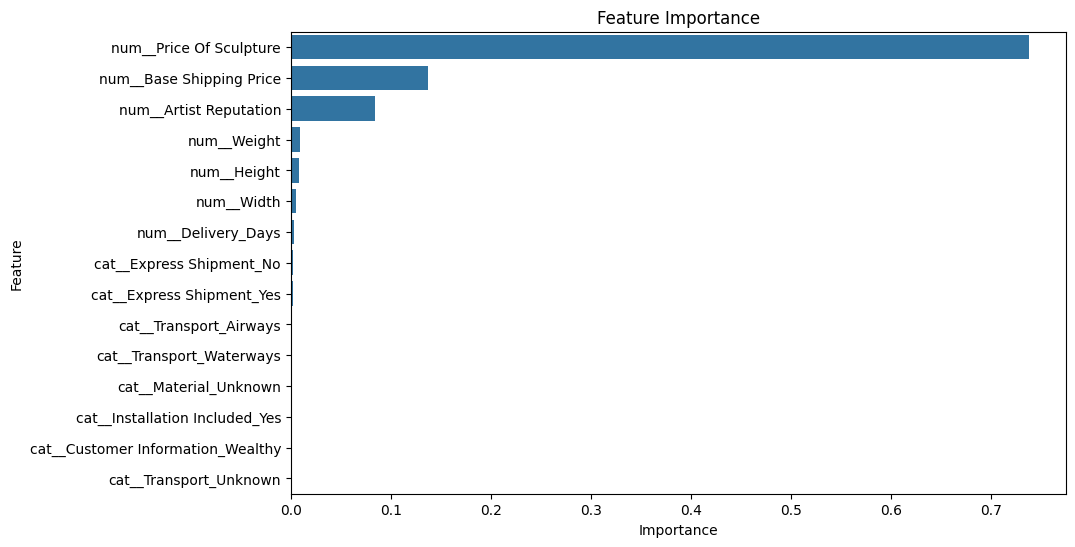

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [250]:
xgb = XGBRegressor(
    random_state=42
)

xgb.fit(X_train_array, y_train)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
4,num__Price Of Sculpture,0.658589
5,num__Base Shipping Price,0.112917
0,num__Artist Reputation,0.057343
17,cat__Express Shipment_No,0.033930
21,cat__Transport_Airways,0.011776
19,cat__Installation Included_No,0.011346
1,num__Height,0.009385
27,cat__Customer Information_Wealthy,0.008648
3,num__Weight,0.008545
24,cat__Transport_Waterways,0.008218


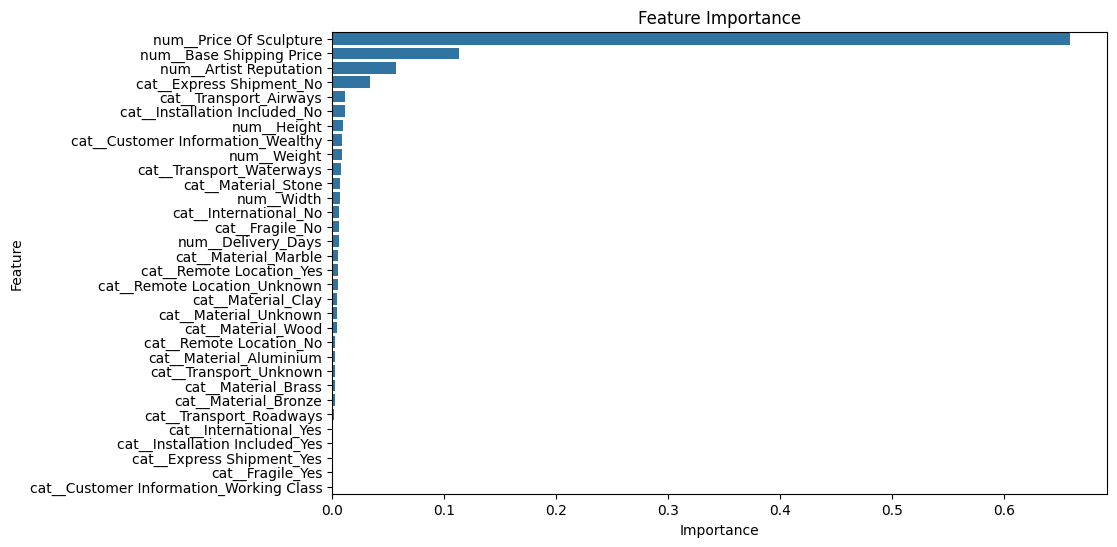

In [252]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

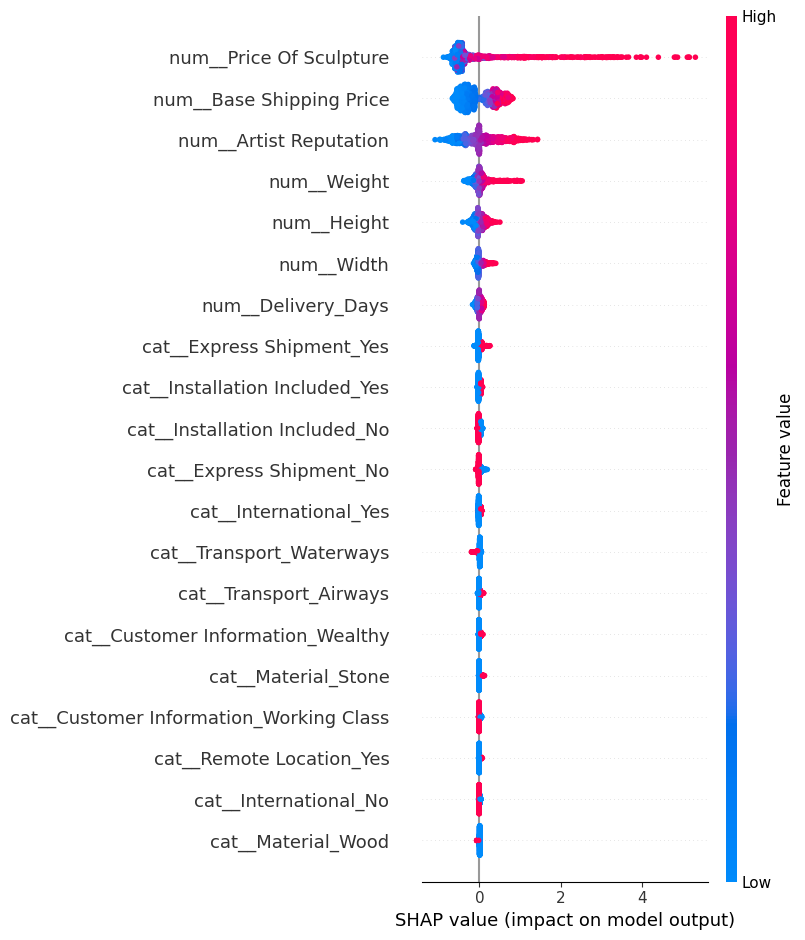

In [247]:
from catboost import CatBoostRegressor, Pool
import shap

cat = CatBoostRegressor(verbose=0, random_state=42)
cat.fit(X_train_array, y_train)

pool = Pool(X_test_array)

shap_values = cat.get_feature_importance(pool, type="ShapValues")
shap_values_data = shap_values[:, :-1]

feature_names = preprocessor.get_feature_names_out()

X_test_shap = pd.DataFrame(
    X_test_array,
    columns=feature_names
)

shap.summary_plot(
    shap_values_data,
    X_test_shap
)